<a href="https://colab.research.google.com/github/priyal6/General-llm/blob/main/multimodalembed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers torch torchvision pillow requests

In [2]:
import torch
from transformers import CLIPModel, CLIPProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print(f"Loaded CLIP on {device}")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Loaded CLIP on cuda


In [3]:
import torch.nn.functional as F

def embed_images(images):
  inputs = processor(images=images, return_tensors="pt").to(device)
  with torch.no_grad():
    features = model.get_image_features(**inputs)
  return F.normalize(features, dim=-1)

def embed_text(texts):
  inputs = processor(text=texts, return_tensors="pt", padding=True).to(device)
  with torch.no_grad():
    features = model.get_text_features(**inputs)
  return F.normalize(features, dim=-1)

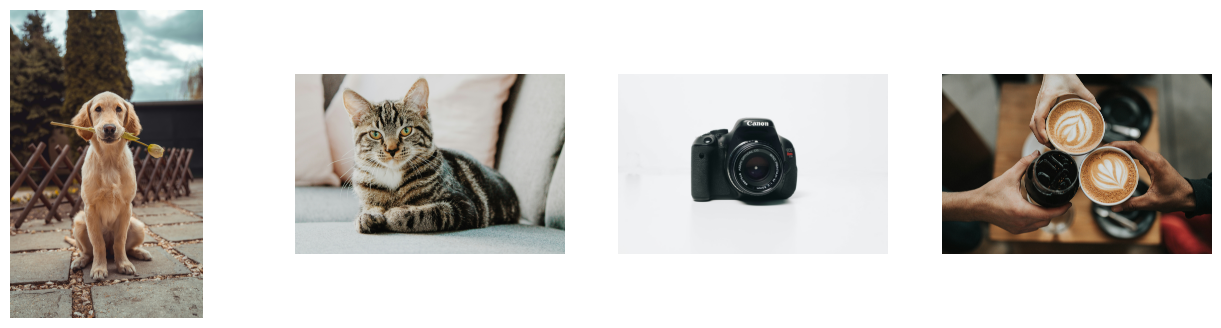

In [4]:
import requests
from PIL import Image
from io import BytesIO

image_urls = [
    "https://images.unsplash.com/photo-1552053831-71594a27632d",  # dog
    "https://images.unsplash.com/photo-1518791841217-8f162f1e1131",  # cat
    "https://images.unsplash.com/photo-1502920917128-1aa500764cbd",  # mountains
    "https://images.unsplash.com/photo-1495474472287-4d71bcdd2085",  # laptop code
]

images = []
for url in image_urls:
  resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
  img = Image.open(BytesIO(resp.content)).convert("RGB")
  images.append(img)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(images), figsize=(16, 4))
for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis("off")
plt.show()

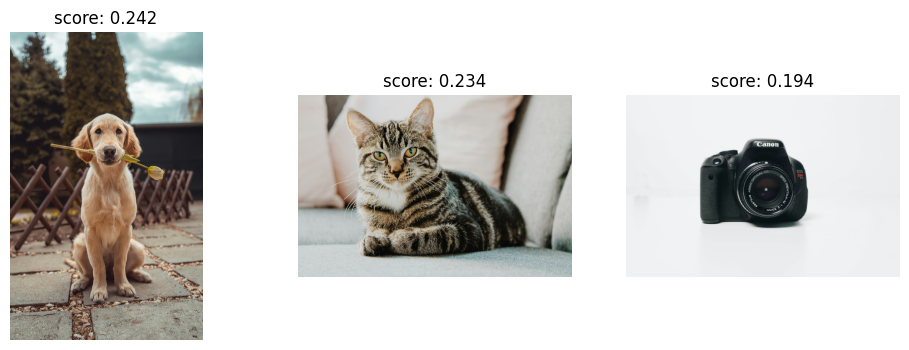

In [6]:
def embed_images(images):
  inputs = processor(images=images, return_tensors="pt").to(device)
  with torch.no_grad():
    features = model.get_image_features(**inputs)
  return F.normalize(features.pooler_output, dim=-1)

def embed_text(texts):
  inputs = processor(text=texts, return_tensors="pt", padding=True).to(device)
  with torch.no_grad():
    features = model.get_text_features(**inputs)
  return F.normalize(features.pooler_output, dim=-1)

image_embeds = embed_images(images)

def search(query, top_k=3):
  query_embed = embed_text([query])
  sims = (query_embed @ image_embeds.T).squeeze(0)
  top = sims.topk(min(top_k, len(images)))

  fig, axes = plt.subplots(1, len(top.indices), figsize=(4 * len(top.indices), 4))
  if len(top.indices) == 1:
    axes = [axes]
  for ax, idx, score in zip(axes, top.indices, top.values):
    ax.imshow(images[idx])
    ax.set_title(f"score: {score:.3f}")
    ax.axis("off")
  plt.show()

search("a fully animal")

In [7]:
def classify(images, labels):
  text_embeds = embed_text(labels)
  img_embed = embed_images([images])
  sims = (img_embed @ text_embeds.T).squeeze(0)
  probs = sims.softmax(dim=0)
  for label, p in sorted(zip(labels, probs), key=lambda x: -x[1]):
    print(f"{label:20s} {p.item():.3f}")

classify(images[0], ["a dog", "a cat", "a landscape", "a piece of technology"])

a dog                0.261
a piece of technology 0.249
a cat                0.248
a landscape          0.242


Docling

In [4]:
%pip install -q docling[vlm]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.9/732.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.8/286.8 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.4/94.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472

In [5]:
from IPython import display
from pydantic import BaseModel, Field
from rich import print

In [6]:
file_path = (
    "https://upload.wikimedia.org/wikipedia/commons/9/9f/Swiss_QR-Bill_example.jpg"
)
display.HTML(f"<img src='{file_path}' height='1000'>")

In [7]:
from docling.datamodel.base_models import InputFormat
from docling.document_extractor import DocumentExtractor


extractor = DocumentExtractor(allowed_formats=[InputFormat.IMAGE, InputFormat.PDF])

In [8]:
result = extractor.extract(
    source=file_path,
    template='{"bill_no": "string", "total": "float"}',
)
print(result.pages)

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[
    ExtractedPageData(
        page_no=1,
        extracted_data={'bill_no': '3139', 'total': 3949.75},
        raw_text='{"bill_no": "3139", "total": 3949.75}',
        errors=[]
    )
]

In [9]:
from typing import Optional

class Invoice(BaseModel):
  bill_no: str = Field(
      examples=["A123", "5414"]
  )
  total: float = Field(
      default=10, examples=[20]
  )
  tax_id: Optional[str] = Field(
      default=None, examples=["1234567890"]
  )

In [10]:
result = extractor.extract(
    source=file_path,
    template=Invoice,
)

print(result.pages)

[
    ExtractedPageData(
        page_no=1,
        extracted_data={'bill_no': '3139', 'total': 3949.75, 'tax_id': None},
        raw_text='{"bill_no": "3139", "total": 3949.75, "tax_id": null}',
        errors=[]
    )
]

In [11]:
result = extractor.extract(
    source=file_path,
    template=Invoice(
        bill_no="41",
        total=100,
        tax_id="42"
    )
)

In [12]:
class Contact(BaseModel):
  name: Optional[str] = Field(default=None, examples=["Smith"])
  address: str = Field(default="123 Main St", examples=["456 Elm St"])
  postal_code: str = Field(default="12345", examples=["67890"])
  city: str = Field(default="Anytown", examples=["Othertown"])
  country: Optional[str] = Field(default=None, examples=["Canada"])

class ExtendedInvoice(BaseModel):
  bill_no: str = Field(
      examples=["A123", "5414"]
  )
  total: float = Field(
      default=10, examples=[20]
  )
  garden_work_hours: int = Field(default=1, examples=[2])
  sender: Contact = Field(default=Contact(), examples=[Contact()])
  receiver: Contact = Field(default=Contact(), examples=[Contact()])

In [13]:
result = extractor.extract(
    source=file_path,
    template=ExtendedInvoice,
)
print(result.pages)

[
    ExtractedPageData(
        page_no=1,
        extracted_data={
            'bill_no': '3139',
            'total': 3667.35,
            'garden_work_hours': 28,
            'sender': {
                'name': 'Robert Schneider',
                'address': 'Rue du Lac 1268',
                'postal_code': '2501 Biel',
                'city': 'Rorschach',
                'country': 'CH'
            },
            'receiver': {
                'name': 'Pia Rutschmann',
                'address': 'Marktgasse 28',
                'postal_code': '9400 Rorschach',
                'city': 'Rorschach',
                'country': 'CH'
            }
        },
        raw_text='{"bill_no": "3139", "total": 3667.35, "garden_work_hours": 28, "sender": {"name": "Robert 
Schneider", "address": "Rue du Lac 1268", "postal_code": "2501 Biel", "city": "Rorschach", "country": "CH"}, 
"receiver": {"name": "Pia Rutschmann", "address": "Marktgasse 28", "postal_code": "9400 Rorschach", "city": 
"Rorschach", "country": "CH"}}',
        errors=[]
    )
]

In [15]:
invoice = ExtendedInvoice.model_validate(result.pages[0].extracted_data)
print(invoice)

ExtendedInvoice(
    bill_no='3139',
    total=3667.35,
    garden_work_hours=28,
    sender=Contact(
        name='Robert Schneider',
        address='Rue du Lac 1268',
        postal_code='2501 Biel',
        city='Rorschach',
        country='CH'
    ),
    receiver=Contact(
        name='Pia Rutschmann',
        address='Marktgasse 28',
        postal_code='9400 Rorschach',
        city='Rorschach',
        country='CH'
    )
)

In [16]:
print(
    f"Invoice #{invoice.bill_no} was sent by {invoice.sender.name} "
    f"to {invoice.receiver.name} at {invoice.sender.address}."
)

Invoice #3139 was sent by Robert Schneider to Pia Rutschmann at Rue du Lac 1268.